In [3]:
import pandas as pd
import numpy as np
import shap
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
from xgboost import XGBClassifier

processed_path = Path('../data/processed')
models_path = Path('../models')

X_train = pd.read_csv(processed_path / 'X_train.csv')
X_test  = pd.read_csv(processed_path / 'X_test.csv')
y_train = pd.read_csv(processed_path / 'y_train.csv').squeeze()
y_test  = pd.read_csv(processed_path / 'y_test.csv').squeeze()

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (3539, 41)
X_test:  (885, 41)


In [4]:
model = XGBClassifier(
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),
    n_estimators=100, random_state=42, eval_metric='logloss',
    objective='binary:logistic', base_score=0.5
)
model.fit(X_train, y_train)
print("Model trained")

Model trained


In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer ready")

with open(models_path / 'shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print("SHAP explainer saved")

SHAP values shape: (885, 41)
SHAP explainer ready
SHAP explainer saved


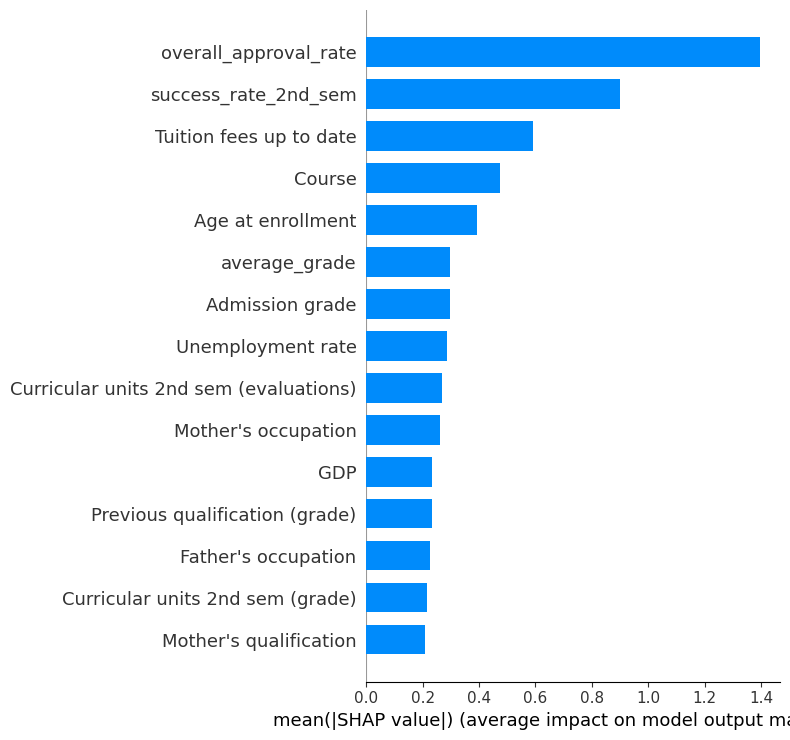

In [6]:
shap.summary_plot(shap_values, X_test, plot_type='bar', max_display=15)

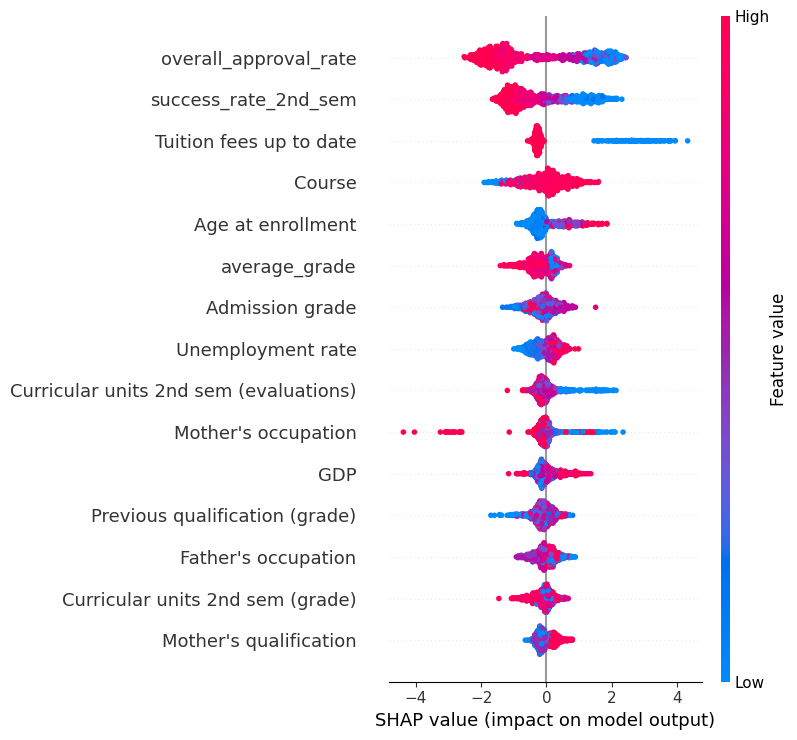

In [7]:
shap.summary_plot(shap_values, X_test, max_display=15)

Student index: 2
Predicted probability: 99.17%
Actual label: Dropout


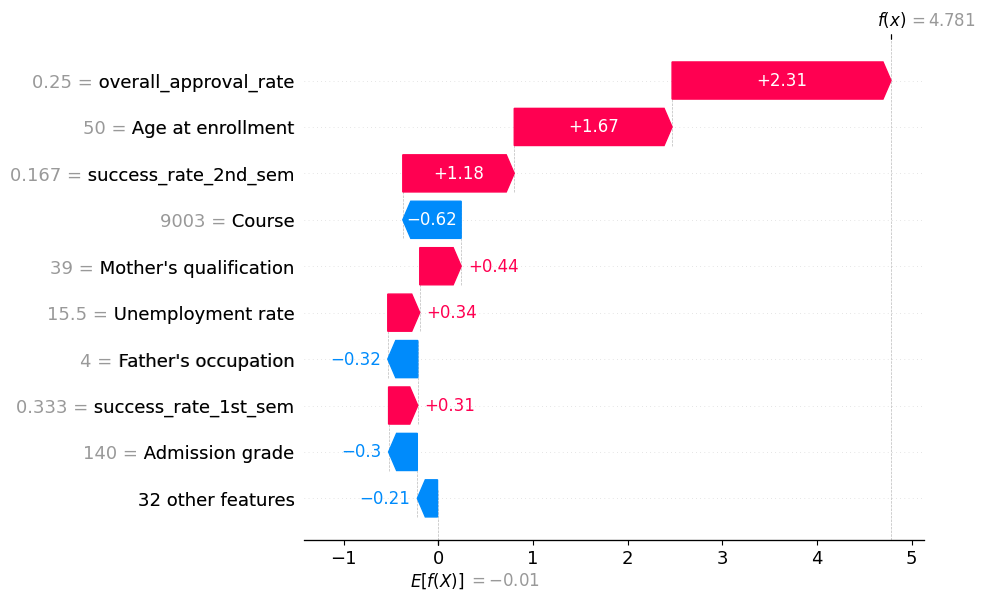

In [8]:
dropout_indices = y_test[y_test == 1].index
sample_idx = dropout_indices[0]
pos = X_test.index.get_loc(sample_idx)

print(f"Student index: {sample_idx}")
print(f"Predicted probability: {model.predict_proba(X_test.iloc[[pos]])[:,1][0]:.2%}")
print(f"Actual label: Dropout")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[pos],
        base_values=explainer.expected_value,
        data=X_test.iloc[pos].values,
        feature_names=X_test.columns.tolist()
    )
)